# calling the important libraries

In [ ]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



importing the google drive and uploading the file

In [ ]:
cpx_combined = pd.read_excel('/content/Combined Datasets EPMA.xlsx',
                             sheet_name= 'cpx combined'
                             )

In [ ]:
cpx_combined

,SAMPLE,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,...,Lu,Hf,Ta,Pb,Th,U,C,M,R,T
0,KL2023-07-19-4_1,0.005,0.023,22.625,44.409,0.231,0.758,3.365,0.051,0.081,...,0.188,3.74,0.208,0.038,0.096,0.0176,1,0,0,3
1,KL2023-07-19-4_2,0.000,0.124,22.752,47.643,0.302,0.764,2.058,0.031,0.017,...,0.184,3.03,0.238,0.054,0.103,0.0157,0,1,0,3
2,KL2023-07-19-4_3,0.014,0.000,22.711,49.580,0.189,0.539,1.448,0.033,0.141,...,0.225,4.09,0.188,0.06,0.113,0.0135,0,0,1,3
3,KL2023-07-19-4_4,0.000,0.000,23.481,51.316,0.1,0.534,0.057,0.050,0.421,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,3
4,KL2023-07-19-4_5,0.000,0.000,23.601,51.941,0.118,0.423,0.139,0.074,0.388,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,KL2023-07-25-8_43,0.000,0.000,23.304,47.393,0.026,0.748,1.640,0.018,0.106,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,2
414,KL2023-07-25-8_44,0.009,0.000,23.196,47.737,0.092,0.603,1.741,0.035,0.136,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,2
415,KL2023-07-25-8_45,0.011,0.098,23.203,46.864,0.031,0.646,1.915,0.045,0.100,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,2
416,KL2023-07-25-8_46,0.018,0.000,23.210,45.340,0.071,0.644,2.295,0.077,0.067,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,2


#Only selecting epma dataset

selecting epma dataset from cpx_combined dataframe for EDA, Visualization and preprocessing.

and naming it epma dataframe.

In [ ]:
#to see only epma data

cpx_combined.iloc[:, 0 : 18]

# creating a new dataframe called epma

epma = cpx_combined.iloc[:, 0 : 19]

epma.dtypes

,0
SAMPLE,object
NiO,float64
F,float64
CaO,float64
SiO2,float64
Cr2O3,object
Na2O,float64
TiO2,float64
V2O3,float64
MnO,float64


Only selecting relevant columns to check the statistical nature.
creating new dataframe by removing the first column sample.

In [ ]:
epma_no_sample = epma.iloc[:,1:19] # creating new dataframe by removing the first column sample.
epma_no_sample.dtypes

,0
NiO,float64
F,float64
CaO,float64
SiO2,float64
Cr2O3,float64
Na2O,float64
TiO2,float64
V2O3,float64
MnO,float64
MgO,float64


found that one column Cr2O3 has object dtype. which is unmatchable.

In [ ]:
#checking the values of column Cr2O3

epma['Cr2O3']

,Cr2O3
0,0.231
1,0.302
2,0.189
3,0.100
4,0.118
...,...
413,0.026
414,0.092
415,0.031
416,0.071


#converting the object dtype of Cr2O3 into float.

In [ ]:
'''
Ensuring All Values Are Strings Before Using .str: Convert the column to str before applying .str methods.
This prevents errors when dealing with mixed types (e.g., float, NaN, etc.).
'''
invalid_entries = epma[~epma['Cr2O3'].astype(str).str.replace('.', '', 1).str.isnumeric()]
print(invalid_entries)

# found negative oxide value percentage and string value CPX in Cr2O3.

                SAMPLE       NiO    F     CaO     SiO2    Cr2O3     Na2O  \
358  KL2023-07-25-7_29  0.015533  0.0  22.094  45.6748 -0.01734  1.00859   

        TiO2  V2O3       MnO      MgO  ZnO      FeO   Al2O3       K2O  Li2O  \
358  1.81326   0.0  0.217395  10.1537  0.0  9.97681  7.9654  0.011418   0.0   

     Total with Li2O      Total   Mg#  
358        98.913566  98.913566  0.64  


In [ ]:
invalid_entries = epma[~epma['Cr2O3']
                                 .fillna('')  # Replace NaN with empty strings
                                 .astype(str)
                                 .str.replace('.', '', 1)
                                 .str.isnumeric()]
print(invalid_entries)


                SAMPLE       NiO    F     CaO     SiO2    Cr2O3     Na2O  \
358  KL2023-07-25-7_29  0.015533  0.0  22.094  45.6748 -0.01734  1.00859   

        TiO2  V2O3       MnO      MgO  ZnO      FeO   Al2O3       K2O  Li2O  \
358  1.81326   0.0  0.217395  10.1537  0.0  9.97681  7.9654  0.011418   0.0   

     Total with Li2O      Total   Mg#  
358        98.913566  98.913566  0.64  


In [ ]:
print(epma['Cr2O3'].head())
print(epma['Cr2O3'].dtype)


0    0.231
1    0.302
2    0.189
3    0.100
4    0.118
Name: Cr2O3, dtype: float64
float64


In [ ]:
'''
Replace non-numeric entries with a specific value:
'''
epma['Cr2O3'] = pd.to_numeric(epma['Cr2O3'], errors='coerce').fillna(0)  # Replace NaN with 0


In [ ]:
epma['Cr2O3'].dtype

dtype('float64')

In [ ]:
epma['Cr2O3'].min() # unexpected negative value.

-0.01734

#**Compositional Range:**

What is the range of values for major oxides (e.g., SiO₂, CaO, TiO₂)?

In [ ]:
epma_no_sample.columns

Index(['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O', 'Total with Li2O', 'Total',
       'Mg#'],
      dtype='object')

In [ ]:
import pandas as pd


# Calculate the range of values for the major oxides
major_oxides = ['CaO','SiO2','TiO2','MgO','FeO','Al2O3']
ranges = epma[major_oxides].agg(['min', 'max'])

# Print the range of values
print("Range of values for the major oxides:")
print(ranges)


Range of values for the major oxides:
        CaO    SiO2   TiO2     MgO     FeO   Al2O3
min  20.626  39.168  0.057   5.911   3.856   0.536
max  24.455  51.973  4.350  15.880  16.404  14.837


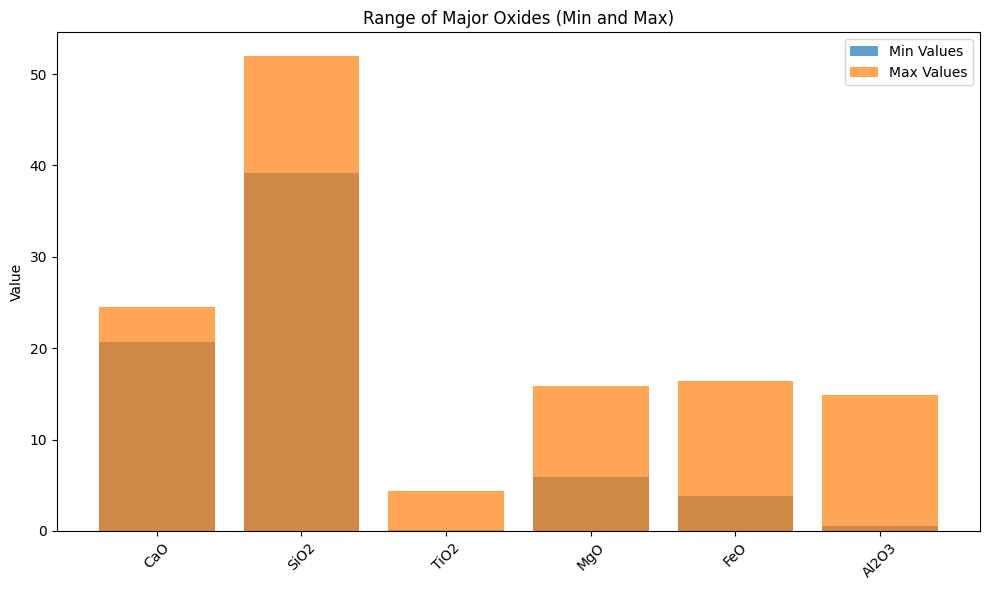

In [ ]:
# Visualization: Bar chart for min and max values
plt.figure(figsize=(10, 6))
x_labels = ranges.columns
min_values = ranges.loc['min']
max_values = ranges.loc['max']

# Plot min values
plt.bar(x_labels, min_values, alpha=0.7, label='Min Values')
# Plot max values
plt.bar(x_labels, max_values, alpha=0.7, label='Max Values')

# Add labels, title, and legend
plt.ylabel('Value')
plt.title('Range of Major Oxides (Min and Max)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

#**Chemical Variability:**

 How variable is each component across the dataset? Which are the most stable or variable?

In [ ]:
import pandas as pd



# Calculate the standard deviation for each component
std_devs = epma_no_sample.std()

# Calculate the coefficient of variation (CV) for each component
cv = std_devs / epma_no_sample.mean()

# Combine standard deviation and CV into a single DataFrame for better comparison
variability = pd.DataFrame({'Standard Deviation': std_devs, 'CV': cv})

# Sort by standard deviation (higher means more variable)
variability_sorted_std = variability.sort_values(by='Standard Deviation', ascending=False)

# Sort by CV (higher means more variable relative to the mean)
variability_sorted_cv = variability.sort_values(by='CV', ascending=False)

# Display the results
print("Chemical Variability (Standard Deviation and Coefficient of Variation):")
print("\nSorted by Standard Deviation (most variable first):")
print(variability_sorted_std[['Standard Deviation']])
print("\nSorted by Coefficient of Variation (most variable relative to mean):")
print(variability_sorted_cv[['CV']])


Chemical Variability (Standard Deviation and Coefficient of Variation):

Sorted by Standard Deviation (most variable first):
                 Standard Deviation
SiO2                       2.171170
FeO                        2.005801
Al2O3                      1.941760
MgO                        1.804440
TiO2                       0.694869
Total                      0.581919
CaO                        0.572686
Total with Li2O            0.395147
Li2O                       0.361637
Na2O                       0.244873
Cr2O3                      0.111657
Mg#                        0.083183
MnO                        0.071654
F                          0.038296
ZnO                        0.030741
V2O3                       0.027708
NiO                        0.018414
K2O                        0.011400

Sorted by Coefficient of Variation (most variable relative to mean):
                       CV
F                1.946010
ZnO              1.577820
NiO              1.490809
Li2O             

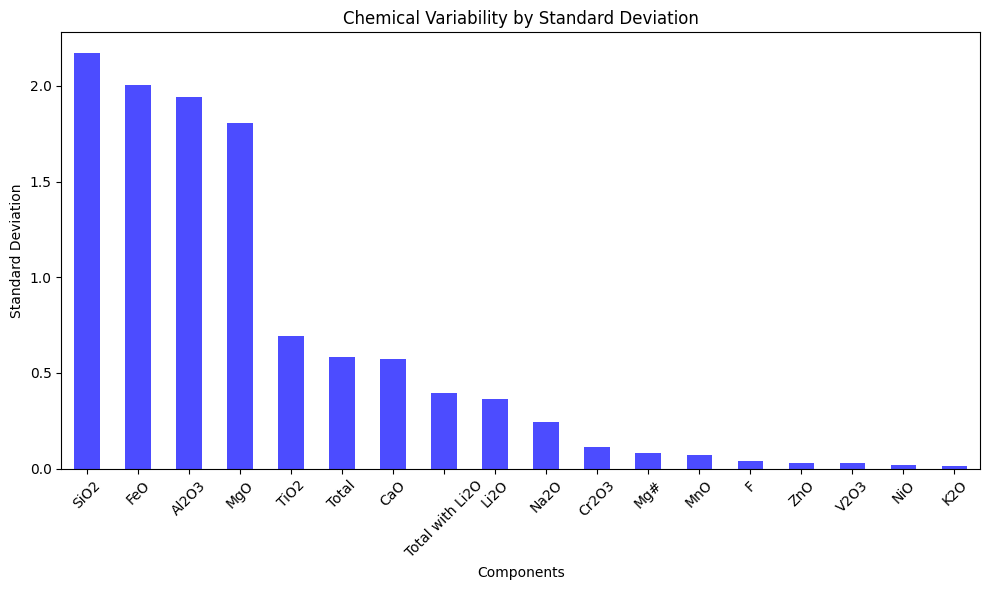

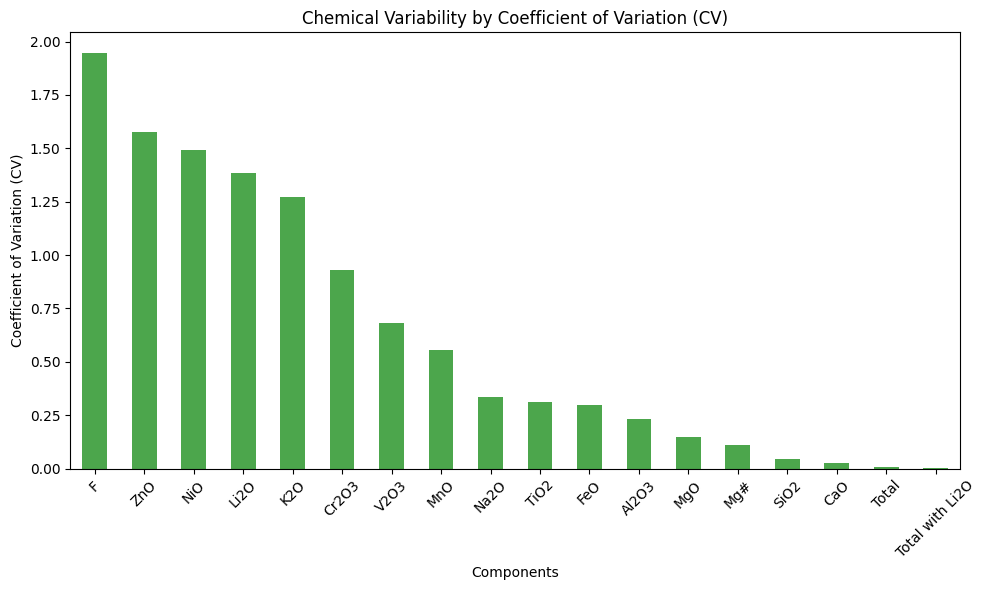

In [ ]:
# Visualization: Bar charts for standard deviation and CV

# Plot for Standard Deviation
plt.figure(figsize=(10, 6))
variability_sorted_std['Standard Deviation'].plot(kind='bar', color='blue', alpha=0.7)
plt.title('Chemical Variability by Standard Deviation')
plt.ylabel('Standard Deviation')
plt.xlabel('Components')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot for Coefficient of Variation
plt.figure(figsize=(10, 6))
variability_sorted_cv['CV'].plot(kind='bar', color='green', alpha=0.7)
plt.title('Chemical Variability by Coefficient of Variation (CV)')
plt.ylabel('Coefficient of Variation (CV)')
plt.xlabel('Components')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**statistical summries:**

**Central Tendency:**

What are the mean, median, and mode for each component (e.g., major oxides and trace elements)?

**Dispersion:** What are the standard deviation, variance, and interquartile range for each variable?

**Distribution Shape:** Are the distributions for each component symmetric, skewed, or multimodal?

**Central Tendency:**

What are the mean, median, and mode for each component (e.g., major oxides and trace elements)?

In [ ]:
import pandas as pd

# Calculate mean, median, and mode for each column
central_tendency = pd.DataFrame({
    'Mean': epma_no_sample.mean(),
    'Median': epma_no_sample.median(),
    'Mode': epma_no_sample.mode().iloc[0]
})

# Display the results
central_tendency


,Mean,Median,Mode
NiO,0.012352,0.000000,0.000
F,0.019679,0.000000,0.000
CaO,22.766269,22.792500,21.877
SiO2,46.557545,46.751000,47.189
Cr2O3,0.120081,0.087000,0.000
Na2O,0.734468,0.663000,0.609
TiO2,2.241251,2.107500,1.599
V2O3,0.040758,0.042000,0.000
MnO,0.128551,0.113946,0.106
MgO,12.032939,12.348500,11.749


<Figure size 1200x800 with 0 Axes>

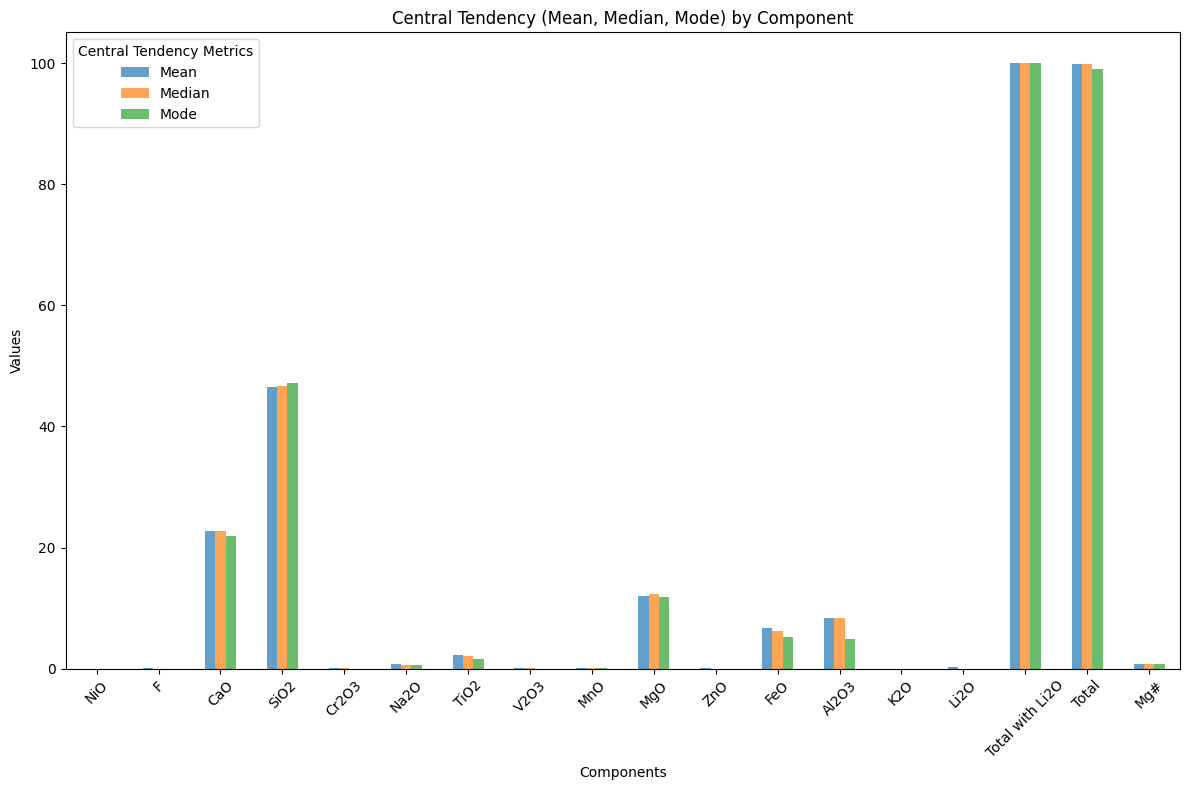

In [ ]:
# Visualization: Grouped Bar Chart for Mean, Median, and Mode
plt.figure(figsize=(12, 8))

# Generate bar chart
central_tendency.plot(kind='bar', figsize=(12, 8), alpha=0.7)

# Customize the plot
plt.title('Central Tendency (Mean, Median, Mode) by Component')
plt.ylabel('Values')
plt.xlabel('Components')
plt.xticks(rotation=45)
plt.legend(title='Central Tendency Metrics')
plt.tight_layout()

# Show the plot
plt.show()

#**Elemental Associations**


Covariation: How do different chemical components co-vary? (e.g., Does TiO₂ increase with FeO?)



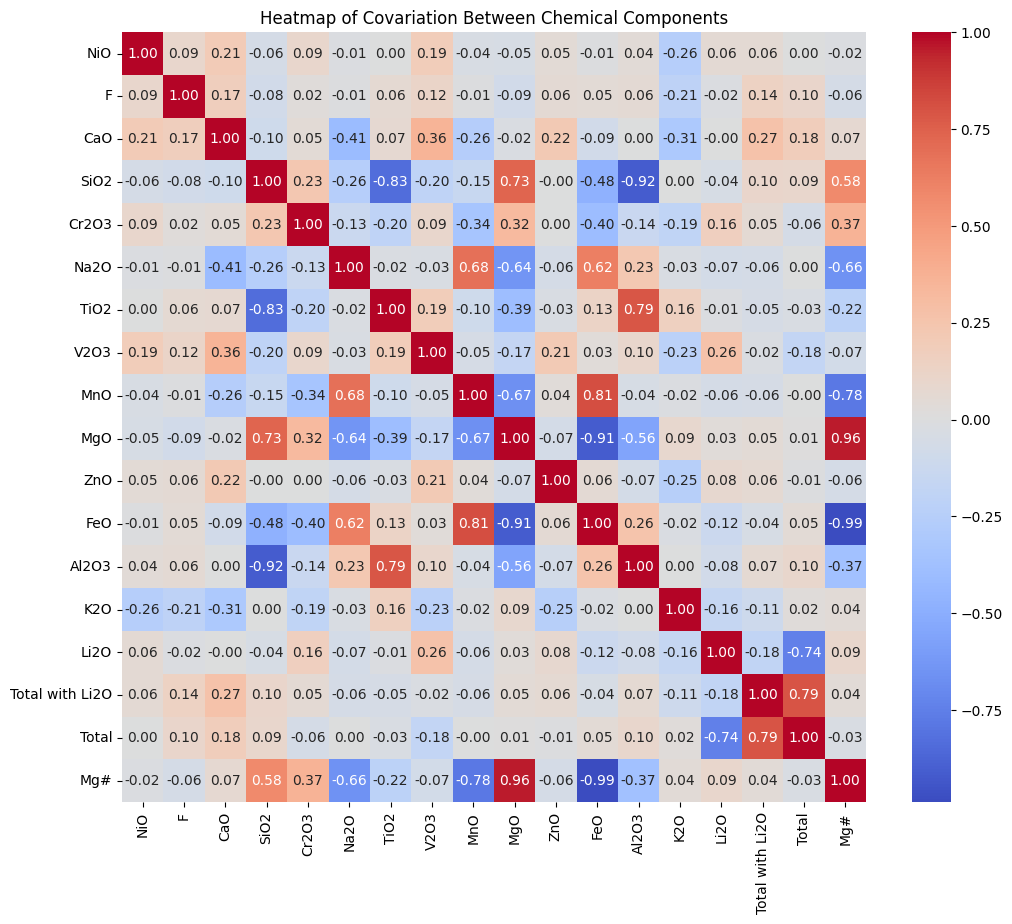

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix to assess covariation
correlation_matrix = epma_no_sample.corr()

# Generate a heatmap for visualizing the covariation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap of Covariation Between Chemical Components")
plt.show()


**Correlation Strength: **

What are the Pearson or Spearman correlations between key elements or oxides?



In [ ]:
# Calculate the Pearson correlation matrix
pearson_correlation = epma_no_sample.corr(method='pearson')

# Calculate the Spearman correlation matrix
spearman_correlation = epma_no_sample.corr(method='spearman')

# Display the results for key elements or oxides
key_oxides = ['CaO','SiO2','TiO2','MgO','FeO','Al2O3']

pearson_corr_selected = pearson_correlation.loc[key_oxides, key_oxides]

spearman_corr_selected = spearman_correlation.loc[key_oxides, key_oxides]

# Display the Pearson and Spearman correlation matrices to the user
print("Pearson Correlation Matrix for Key Oxides", pearson_corr_selected)

print("Spearman Correlation Matrix for Key Oxides", spearman_corr_selected)


Pearson Correlation Matrix for Key Oxides             CaO      SiO2      TiO2       MgO       FeO     Al2O3
CaO    1.000000 -0.102151  0.073366 -0.024064 -0.085628  0.004561
SiO2  -0.102151  1.000000 -0.832628  0.730365 -0.479112 -0.916566
TiO2   0.073366 -0.832628  1.000000 -0.391731  0.126636  0.788718
MgO   -0.024064  0.730365 -0.391731  1.000000 -0.914154 -0.558264
FeO   -0.085628 -0.479112  0.126636 -0.914154  1.000000  0.259047
Al2O3  0.004561 -0.916566  0.788718 -0.558264  0.259047  1.000000
Spearman Correlation Matrix for Key Oxides             CaO      SiO2      TiO2       MgO       FeO     Al2O3
CaO    1.000000 -0.113384  0.079448 -0.101139  0.008799  0.029732
SiO2  -0.113384  1.000000 -0.850432  0.791058 -0.593912 -0.922633
TiO2   0.079448 -0.850432  1.000000 -0.554289  0.386629  0.805985
MgO   -0.101139  0.791058 -0.554289  1.000000 -0.880564 -0.681760
FeO    0.008799 -0.593912  0.386629 -0.880564  1.000000  0.433420
Al2O3  0.029732 -0.922633  0.805985 -0.681760  0.433420  

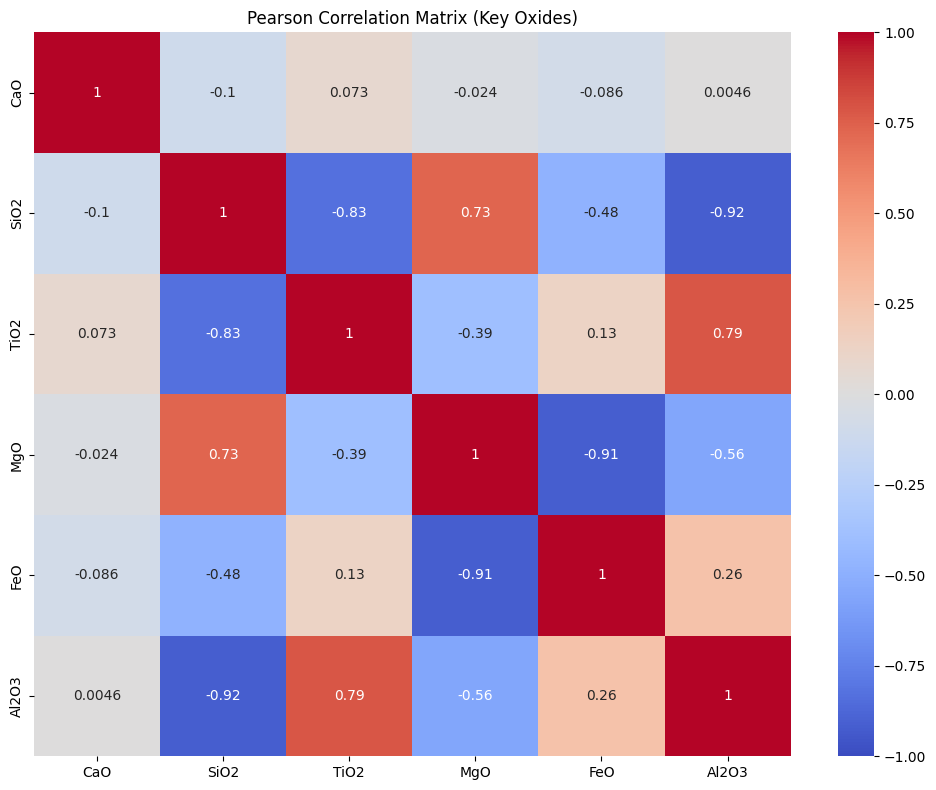

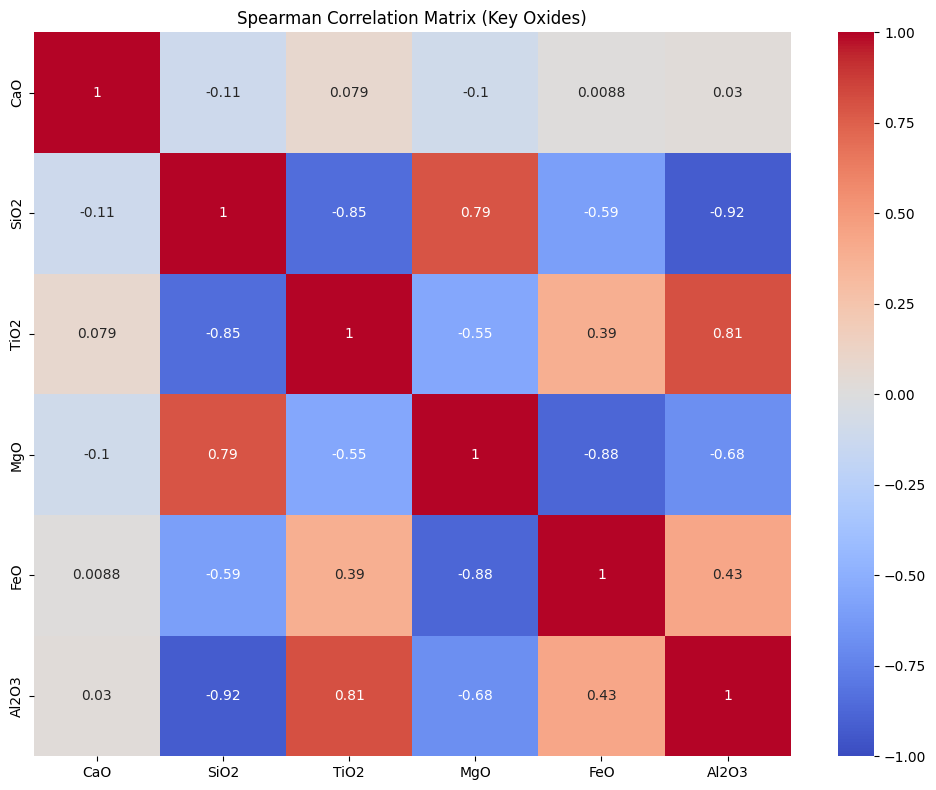

In [ ]:
# Visualization: Heatmaps for Pearson and Spearman Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Pearson Correlation Matrix (Key Oxides)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr_selected, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Spearman Correlation Matrix (Key Oxides)")
plt.tight_layout()
plt.show()

**Elemental Pairings:**

Are certain elements strongly paired due to specific mineralogical relationships (e.g., Al₂O₃ and CaO in plagioclase inclusions)?

In [ ]:
# Focus on the elements of interest (Al2O3 and CaO) for potential mineralogical relationships
key_pair = ['Al2O3', 'CaO']

# Calculate the Pearson and Spearman correlations for the selected pair
pearson_corr_pair = epma_no_sample[key_pair].corr(method='pearson')
spearman_corr_pair = epma_no_sample[key_pair].corr(method='spearman')

# Display the results for the Al2O3-CaO pair
print("Pearson Correlation for Al2O3 and CaO", pearson_corr_pair)
print("Spearman Correlation for Al2O3 and CaO", spearman_corr_pair)


Pearson Correlation for Al2O3 and CaO           Al2O3       CaO
Al2O3  1.000000  0.004561
CaO    0.004561  1.000000
Spearman Correlation for Al2O3 and CaO           Al2O3       CaO
Al2O3  1.000000  0.029732
CaO    0.029732  1.000000


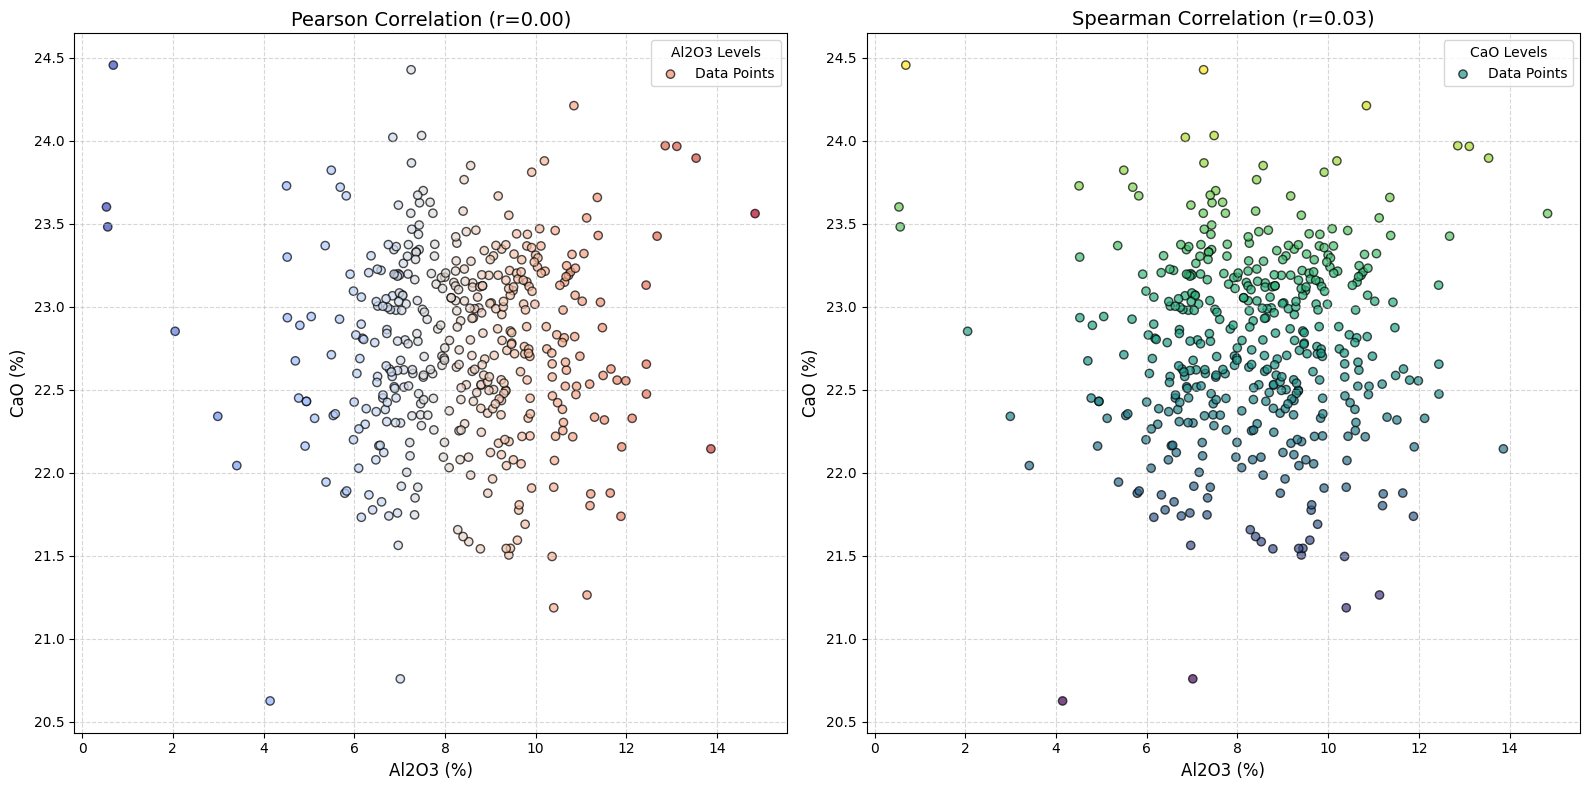

In [ ]:
import matplotlib.pyplot as plt

# Visualization: Separate Subplots for Pearson and Spearman Correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pearson Correlation Subplot
axes[0].scatter(epma_no_sample['Al2O3'], epma_no_sample['CaO'],
                c=epma_no_sample['Al2O3'], cmap='coolwarm', alpha=0.7, edgecolor='k', label='Data Points')
pearson_value = pearson_corr_pair.loc['Al2O3', 'CaO']
axes[0].set_title(f'Pearson Correlation (r={pearson_value:.2f})', fontsize=14)
axes[0].set_xlabel('Al2O3 (%)', fontsize=12)
axes[0].set_ylabel('CaO (%)', fontsize=12)
axes[0].legend(title='Al2O3 Levels', loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Spearman Correlation Subplot
axes[1].scatter(epma_no_sample['Al2O3'], epma_no_sample['CaO'],
                c=epma_no_sample['CaO'], cmap='viridis', alpha=0.7, edgecolor='k', label='Data Points')
spearman_value = spearman_corr_pair.loc['Al2O3', 'CaO']
axes[1].set_title(f'Spearman Correlation (r={spearman_value:.2f})', fontsize=14)
axes[1].set_xlabel('Al2O3 (%)', fontsize=12)
axes[1].set_ylabel('CaO (%)', fontsize=12)
axes[1].legend(title='CaO Levels', loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Adjust layout and display
plt.tight_layout()
plt.show()


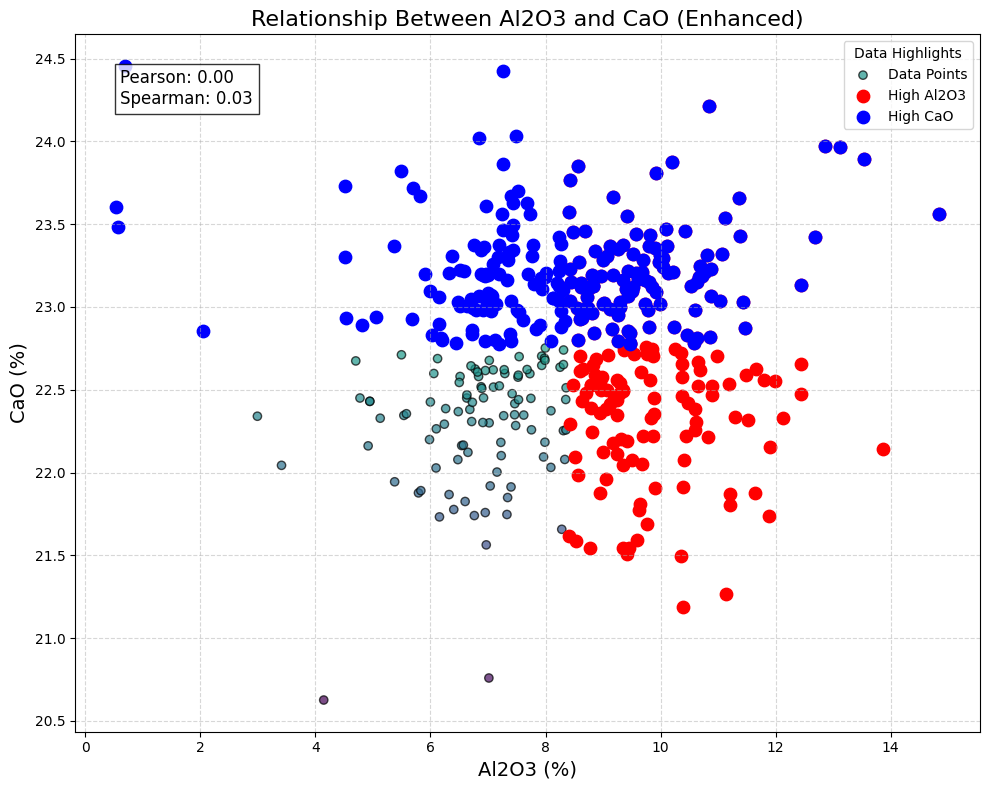

In [ ]:
import matplotlib.pyplot as plt

# Enhanced Visualization: Scatter Plot with Pearson and Spearman Annotations
plt.figure(figsize=(10, 8))

# Scatter plot with customized colors for Al2O3 and CaO
plt.scatter(epma_no_sample['Al2O3'], epma_no_sample['CaO'],
            c=epma_no_sample['CaO'], cmap='viridis',
            alpha=0.7, edgecolor='k', label='Data Points')

# Highlight specific data ranges (e.g., high CaO or high Al2O3)

high_al2o3 = epma_no_sample[epma_no_sample['Al2O3'] > epma_no_sample['Al2O3'].mean()]

high_cao = epma_no_sample[epma_no_sample['CaO'] > epma_no_sample['CaO'].mean()]


plt.scatter(high_al2o3['Al2O3'], high_al2o3['CaO'],
            color='red', s=80, label='High Al2O3')

plt.scatter(high_cao['Al2O3'], high_cao['CaO'],
            color='blue', s=80, label='High CaO')

# Add labels, title, and axis information

plt.title('Relationship Between Al2O3 and CaO (Enhanced)', fontsize=16)

plt.xlabel('Al2O3 (%)', fontsize=14)

plt.ylabel('CaO (%)', fontsize=14)

# Annotate Pearson and Spearman correlations
pearson_value = pearson_corr_pair.loc['Al2O3', 'CaO']
spearman_value = spearman_corr_pair.loc['Al2O3', 'CaO']
annotation_text = f"Pearson: {pearson_value:.2f}\nSpearman: {spearman_value:.2f}"
plt.annotate(annotation_text, xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# Add a legend
plt.legend(title='Data Highlights', fontsize=10, loc='upper right')

# Add a grid
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()


#**Dimensional Trends**

Multi-Dimensional Relationships: How do variables relate in multi-dimensional space? (e.g., pairwise scatterplots for CaO, SiO₂, and Al₂O₃)

Principal Drivers: Which variables explain the most variability in the data?


**Multi-Dimensional Relationships:**

How do variables relate in multi-dimensional space? (e.g., pairwise scatterplots for CaO, SiO₂, and Al₂O₃)



In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# Pairwise scatterplots for CaO, SiO2, and Al2O3
selected_columns = ['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O']
sns.pairplot(epma_no_sample[selected_columns])
plt.suptitle("Pairwise Scatterplots for CaO, SiO2, TiO2, MgO, FeO, Al2O3", y=1.02)
plt.show()



NameError: name 'epma_no_sample' is not defined

In [ ]:
# Principal Component Analysis (PCA) to find principal drivers
pca = PCA()
pca_results = pca.fit_transform(epma_no_sample.iloc[:, :-2])  # Exclude Total and Mg# for meaningful PCA

# PCA component contributions
explained_variance = pca.explained_variance_ratio_ * 100
principal_components = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance (%)': explained_variance
})

# Loadings (contributions of each variable to the PCs)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(explained_variance))],
    index=epma_no_sample.columns[:-2]
)

# Display PCA results to user
print("Explained Variance by Principal Components", principal_components)
print("Variable Loadings on Principal Components", loadings)

Explained Variance by Principal Components    Principal Component  Explained Variance (%)
0                  PC1               70.010290
1                  PC2               23.385376
2                  PC3                2.470510
3                  PC4                1.842160
4                  PC5                0.974501
5                  PC6                0.606525
6                  PC7                0.518245
7                  PC8                0.106361
8                  PC9                0.059358
9                 PC10                0.009353
10                PC11                0.006247
11                PC12                0.005390
12                PC13                0.003246
13                PC14                0.001874
14                PC15                0.000565
15                PC16                0.000000
Variable Loadings on Principal Components                       PC1       PC2       PC3       PC4       PC5       PC6  \
NiO             -0.000231 -0.000318  

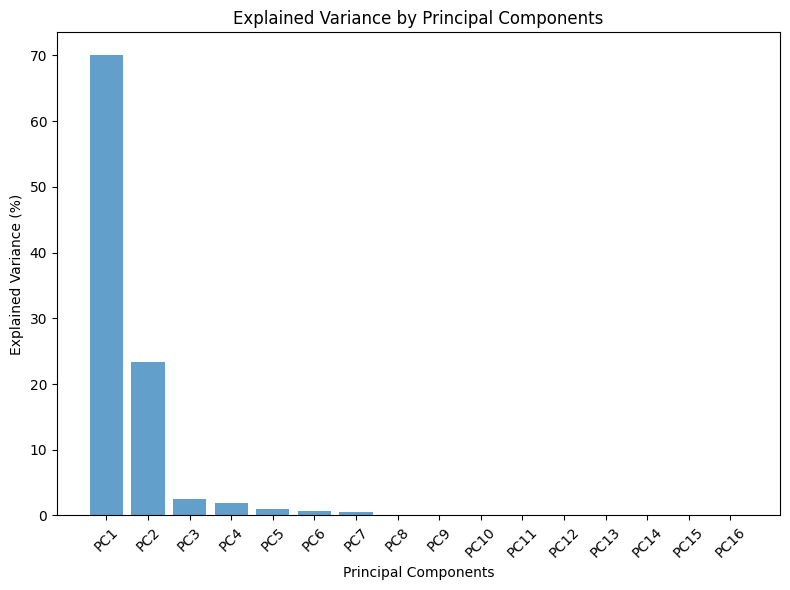

<ipython-input-40-f9a27efc30ac>:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(pc1_loadings[i] + 0.02, pc2_loadings[i], variable, fontsize=10)


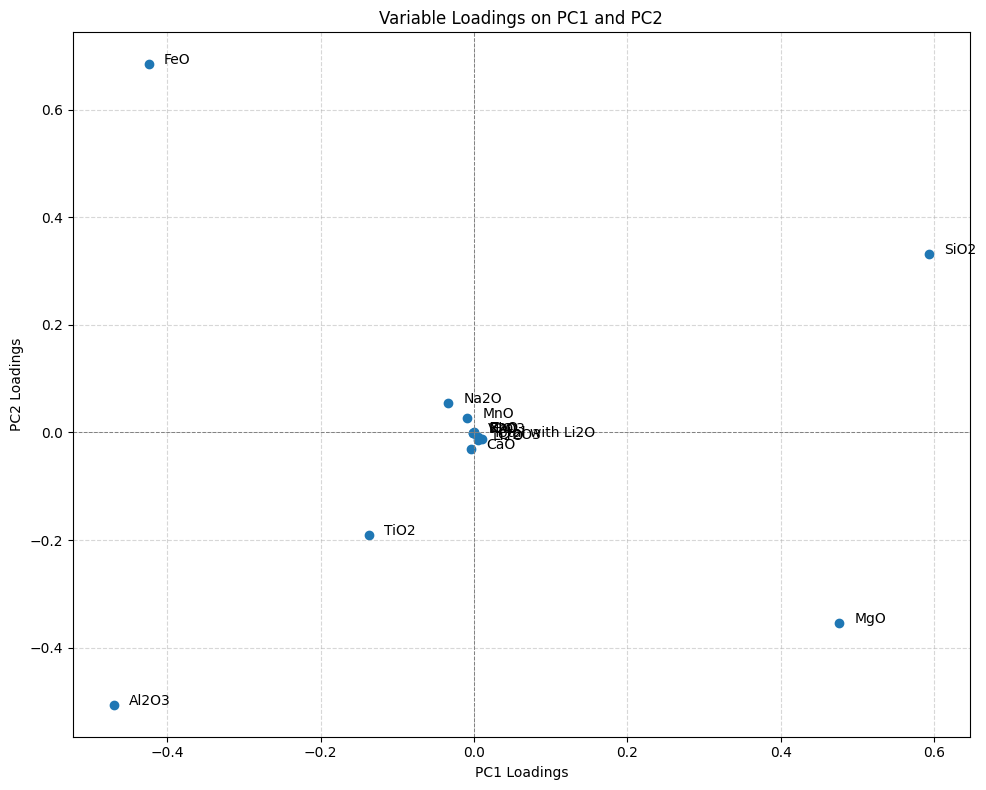

In [ ]:
# Visualization 1: Scree Plot
plt.figure(figsize=(8, 6))
plt.bar(principal_components['Principal Component'], principal_components['Explained Variance (%)'], alpha=0.7)
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 2: Loading Plot for PC1 and PC2
plt.figure(figsize=(10, 8))
pc1_loadings = loadings['PC1']
pc2_loadings = loadings['PC2']

plt.scatter(pc1_loadings, pc2_loadings)
for i, variable in enumerate(loadings.index):
    plt.text(pc1_loadings[i] + 0.02, pc2_loadings[i], variable, fontsize=10)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.title('Variable Loadings on PC1 and PC2')
plt.xlabel('PC1 Loadings')
plt.ylabel('PC2 Loadings')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Principal Drivers:**

Which variables explain the most variability in the data?

#**Derived Metrics**




**Key Ratios:**

What do derived ratios (e.g., CaO/SiO₂, MgO/FeO) reveal about the samples' characteristics?



In [ ]:
# Calculate derived ratios
ratios = pd.DataFrame({
    'CaO/SiO2': epma_no_sample['CaO'] / epma_no_sample['SiO2'],
    'MgO/FeO': epma_no_sample['MgO'] / epma_no_sample['FeO']
})

# Summarize statistics for the ratios
ratios_summary = ratios.describe()

# Display the derived ratios and their statistics
print("Derived Ratios (CaO/SiO2 and MgO/FeO)", ratios)
print("Statistics for Derived Ratios", ratios_summary)


Derived Ratios (CaO/SiO2 and MgO/FeO)      CaO/SiO2   MgO/FeO
0    0.509469  2.317814
1    0.477552  2.640628
2    0.458068  2.861764
3    0.457577  0.449646
4    0.454381  0.514902
..        ...       ...
413  0.491718  1.654155
414  0.485912  2.016229
415  0.495114  2.401142
416  0.511910  1.939123
417  0.509207  1.902603

[418 rows x 2 columns]
Statistics for Derived Ratios          CaO/SiO2     MgO/FeO
count  418.000000  418.000000
mean     0.490135    1.959622
std      0.027485    0.677927
min      0.399249    0.419547
25%      0.471305    1.538984
50%      0.488768    1.969108
75%      0.506523    2.376984
max      0.601537    4.068665


#**Visualization Questions**



**Distribution Plots:**
What do histograms or density plots for each variable reveal about their distributions?



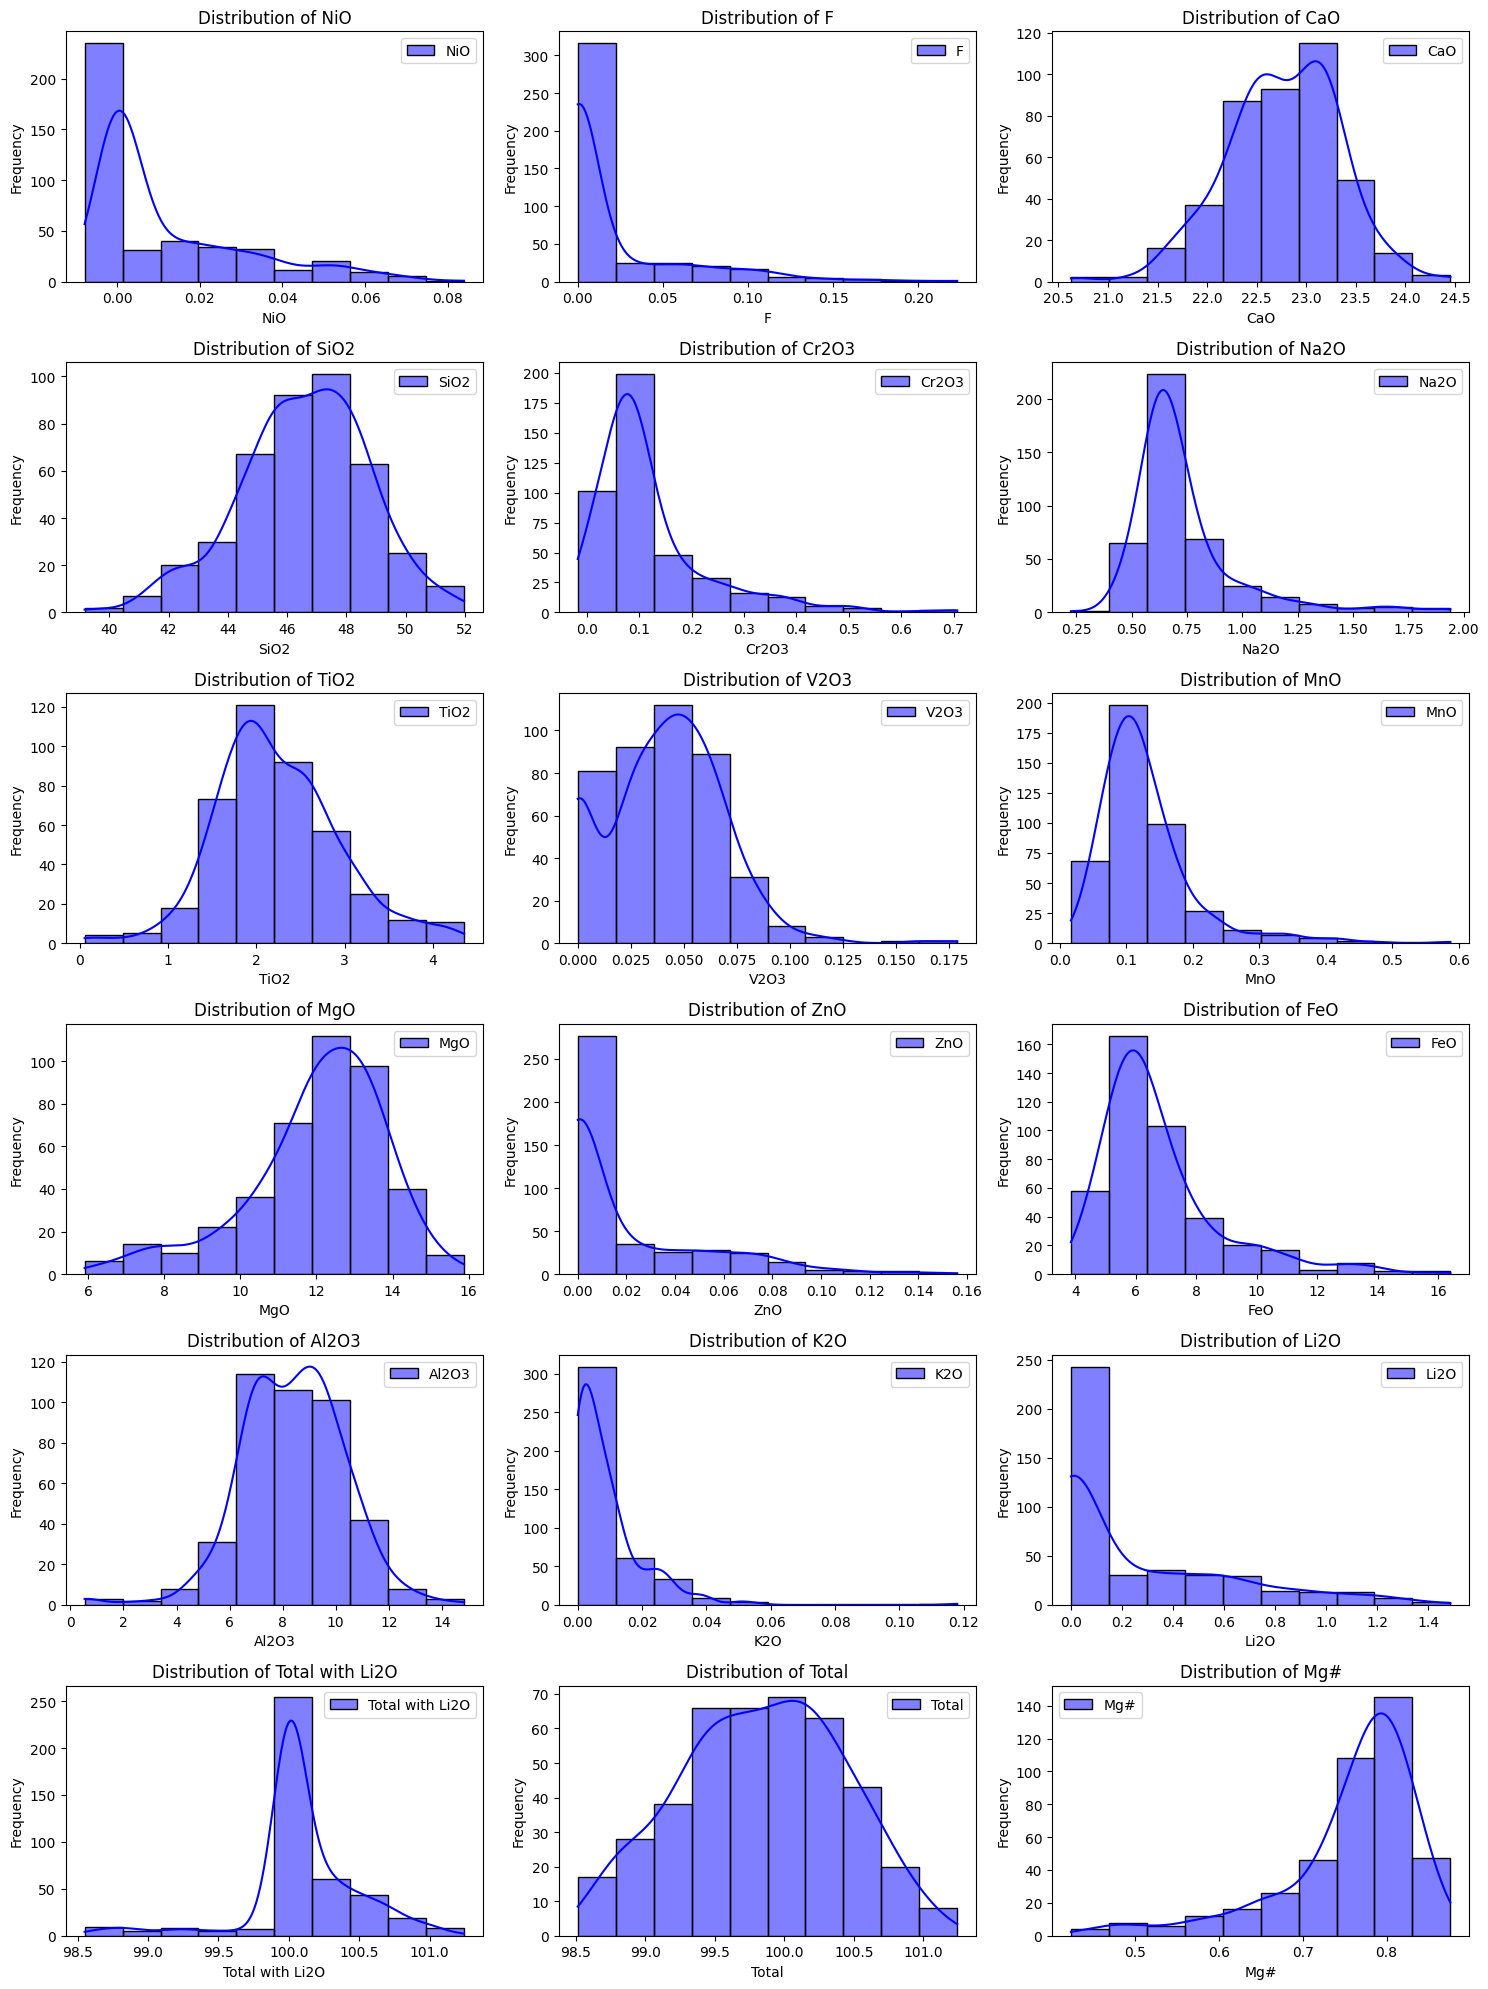

In [ ]:
# Plot histograms and density plots for each variable in the dataset
variables = epma_no_sample.columns

# Create a series of subplots
plt.figure(figsize=(15, 20))
for i, var in enumerate(variables, 1):
    plt.subplot(6, 3, i)  # Adjust rows/columns as needed
    sns.histplot(epma_no_sample[var], kde=True, bins=10, color='blue', label=var)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()




**Ternary Plots:**

Can ternary diagrams reveal compositional trends or clusters (e.g., MgO-CaO-FeO relationships)?



In [ ]:
pip install python-ternary


/usr/local/lib/python3.10/dist-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


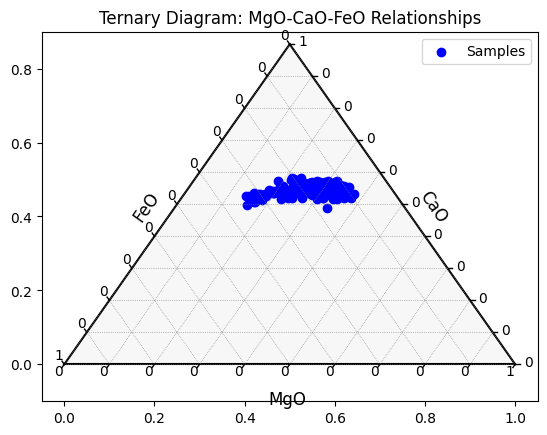

In [ ]:
import matplotlib.pyplot as plt
import ternary

# Select the data for MgO, CaO, and FeO
ternary_data = epma_no_sample[['MgO', 'CaO', 'FeO']]
ternary_data_sum = ternary_data.sum(axis=1)

# Normalize the data for ternary plotting (each row sums to 1)
ternary_normalized = ternary_data.div(ternary_data_sum, axis=0)

# Convert normalized data into a format compatible with the ternary package
ternary_points = ternary_normalized.to_numpy()

# Create a ternary plot
figure, tax = ternary.figure(scale=1.0)
tax.boundary(linewidth=1.5)
tax.gridlines(color="gray", multiple=0.1)

# Plot the points
tax.scatter(ternary_points, marker='o', color='blue', label="Samples")

# Add labels and legend
tax.left_axis_label("FeO", fontsize=12)
tax.right_axis_label("CaO", fontsize=12)
tax.bottom_axis_label("MgO", fontsize=12)
tax.legend()

# Title and show
plt.title("Ternary Diagram: MgO-CaO-FeO Relationships")
tax.ticks(axis='lbr', linewidth=1, multiple=0.1)
plt.show()



**Bivariate Plots:**

How do scatter plots between two key variables look (e.g., TiO₂ vs. Al₂O₃)?

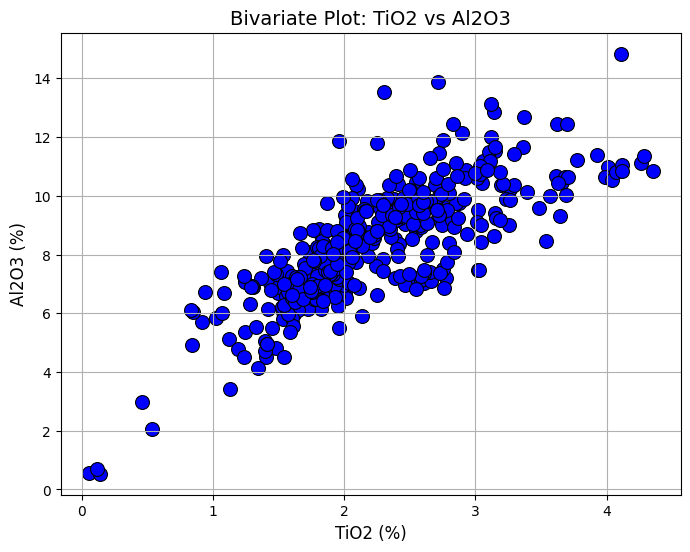

In [ ]:
# Create scatter plots for TiO2 vs Al2O3
plt.figure(figsize=(8, 6))
sns.scatterplot(x=epma_no_sample['TiO2'], y=epma_no_sample['Al2O3'], color='blue', s=100, edgecolor='black')
plt.title("Bivariate Plot: TiO2 vs Al2O3", fontsize=14)
plt.xlabel("TiO2 (%)", fontsize=12)
plt.ylabel("Al2O3 (%)", fontsize=12)
plt.grid(True)
plt.show()




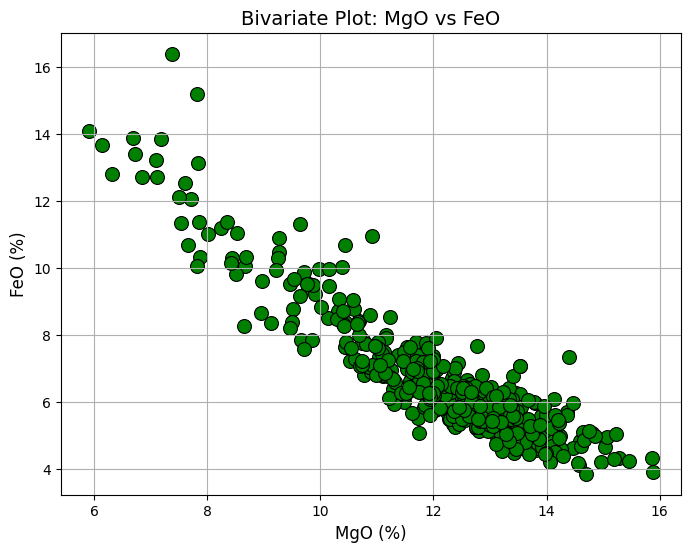

In [ ]:


# Create scatter plots for MgO vs FeO as another key variable combination
plt.figure(figsize=(8, 6))
sns.scatterplot(x=epma_no_sample['MgO'], y=epma_no_sample['FeO'], color='green', s=100, edgecolor='black')
plt.title("Bivariate Plot: MgO vs FeO", fontsize=14)
plt.xlabel("MgO (%)", fontsize=12)
plt.ylabel("FeO (%)", fontsize=12)
plt.grid(True)
plt.show()


**network diagram**

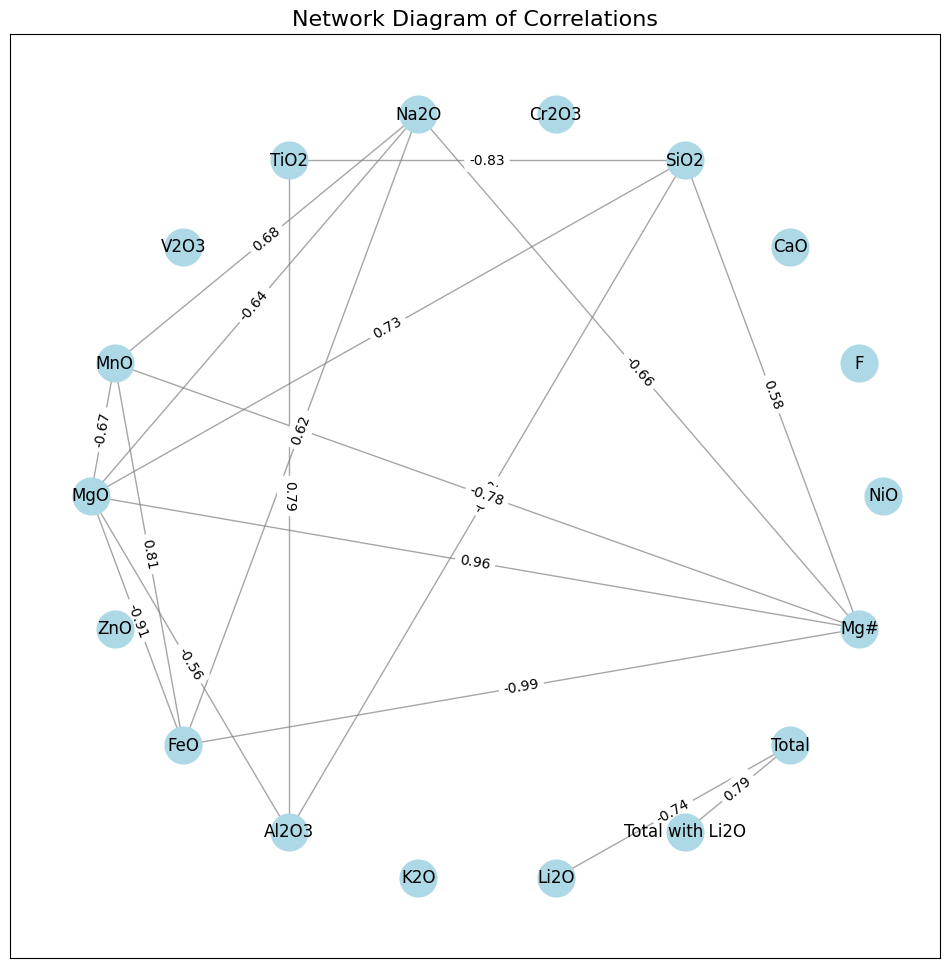

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt



# Create a correlation matrix
correlation_matrix = epma_no_sample.corr()

# Initialize a graph
G = nx.Graph()

# Add nodes for each variable
for variable in correlation_matrix.columns:
    G.add_node(variable)

# Add edges for significant correlations (threshold: 0.5 for absolute value)
threshold = 0.5
for i, var1 in enumerate(correlation_matrix.columns):
    for j, var2 in enumerate(correlation_matrix.columns):
        if i < j and abs(correlation_matrix.iloc[i, j]) > threshold:
            G.add_edge(var1, var2, weight=correlation_matrix.iloc[i, j])

# Define positions for a circular layout
pos = nx.circular_layout(G)

# Draw the network
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=1, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')

# Add edge labels for correlations
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}  # Round to 2 decimal places
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Display the network plot
plt.title("Network Diagram of Correlations", fontsize=16)
plt.show()


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a correlation matrix for network analysis
correlation_matrix = epma_no_sample.corr()

# Initialize a graph
G = nx.Graph()

# Add nodes for each variable
for variable in correlation_matrix.columns:
    G.add_node(variable)

# Add edges for significant correlations (threshold: 0.5 for absolute value)
threshold = 0.5
for i, var1 in enumerate(correlation_matrix.columns):
    for j, var2 in enumerate(correlation_matrix.columns):
        if i < j and abs(correlation_matrix.iloc[i, j]) > threshold:
            G.add_edge(var1, var2, weight=correlation_matrix.iloc[i, j])

# Define positions for a circular layout
pos = nx.circular_layout(G)

# Draw the network
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=1, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')

# Add edge labels for correlations
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}  # Round to 2 decimal places
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Display the network plot
plt.title("Network Diagram of Correlations", fontsize=16)
plt.show()


**Ckusterring analysis:**

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data Preparation: Select numeric oxide columns
oxide_columns = ['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O']  # Replace with your relevant columns
data = epma_no_sample[oxide_columns]

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data)

# Define a function for clustering and metrics evaluation
def clustering_analysis(data, true_labels=None, max_clusters=10):
    metrics = {
        "Silhouette Score": [],
        "SSE": [],
        "Davies-Bouldin Index": []
    }
    for k in range(2, max_clusters + 1):
        # Perform K-Means Clustering
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)

        # Compute evaluation metrics
        metrics["Silhouette Score"].append(silhouette_score(data, labels))
        metrics["SSE"].append(kmeans.inertia_)
        metrics["Davies-Bouldin Index"].append(davies_bouldin_score(data, labels))

        # Compare with true labels if available (ARI, NMI, Purity)
        if true_labels is not None:
            ari = adjusted_rand_score(true_labels, labels)
            nmi = normalized_mutual_info_score(true_labels, labels)
            purity = np.mean([np.max(np.bincount(true_labels[labels == i])) for i in np.unique(labels)])
            print(f"For {k} clusters: ARI={ari:.3f}, NMI={nmi:.3f}, Purity={purity:.3f}")

    # Visualize metrics
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(metrics.keys()):
        plt.subplot(1, 3, i + 1)
        plt.plot(range(2, max_clusters + 1), metrics[metric], marker='o')
        plt.title(metric, fontsize=14)
        plt.xlabel("Number of Clusters")
        plt.ylabel(metric)
        plt.grid(alpha=0.7)
    plt.tight_layout()
    plt.show()

# Perform clustering analysis
clustering_analysis(normalized_data)

# Repeat separately for different oxides if needed
for column in oxide_columns:
    print(f"Clustering analysis for {column}:")
    clustering_analysis(normalized_data[:, [oxide_columns.index(column)]])


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Preparation: Select numeric oxide columns
oxide_columns = ['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O']  # Replace with your relevant columns
data = epma_no_sample[oxide_columns]

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data)

# Function for clustering and metric calculation
def compute_clustering_metrics(data, max_clusters=10):
    metrics = {

        "SSE": []

    }
    for k in range(2, max_clusters + 1):
        # Perform K-Means Clustering
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)

        # Compute metrics

        metrics["SSE"].append(kmeans.inertia_)

    return metrics

# Plot clustering metrics for each oxide in subplots
def plot_clustering_metrics_by_oxide(data, columns, max_clusters=10):
    num_columns = len(columns)
    num_rows = (num_columns + 2) // 3  # Arrange in rows of 3 plots each
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        # Select the data for the current oxide
        single_oxide_data = data[:, [columns.index(column)]]

        # Compute metrics
        metrics = compute_clustering_metrics(single_oxide_data, max_clusters)

        # Create a subplot for the current oxide
        for j, (metric_name, metric_values) in enumerate(metrics.items()):
            sns.lineplot(x=range(2, max_clusters + 1), y=metric_values, ax=axes[i], label=metric_name, marker='o')

        axes[i].set_title(f"SSE Clustering Metrics for {column}", fontsize=14)
        axes[i].set_xlabel("Number of Clusters", fontsize=12)
        axes[i].set_ylabel("Metric Value", fontsize=12)
        axes[i].legend(fontsize=10)
        axes[i].grid(alpha=0.5)

    # Hide extra axes if the grid is larger than the number of columns
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to visualize clustering metrics for each oxide
plot_clustering_metrics_by_oxide(normalized_data, oxide_columns)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Preparation: Select numeric oxide columns
oxide_columns = ['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O']  # Replace with your relevant columns
data = epma_no_sample[oxide_columns]

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data)

# Function for clustering and metric calculation
def compute_clustering_metrics(data, max_clusters=10):
    metrics = {
        "Silhouette Score": [],

    }
    for k in range(2, max_clusters + 1):
        # Perform K-Means Clustering
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)

        # Compute metrics
        metrics["Silhouette Score"].append(silhouette_score(data, labels))

    return metrics

# Plot clustering metrics for each oxide in subplots
def plot_clustering_metrics_by_oxide(data, columns, max_clusters=10):
    num_columns = len(columns)
    num_rows = (num_columns + 2) // 3  # Arrange in rows of 3 plots each
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        # Select the data for the current oxide
        single_oxide_data = data[:, [columns.index(column)]]

        # Compute metrics
        metrics = compute_clustering_metrics(single_oxide_data, max_clusters)

        # Create a subplot for the current oxide
        for j, (metric_name, metric_values) in enumerate(metrics.items()):
            sns.lineplot(x=range(2, max_clusters + 1), y=metric_values, ax=axes[i], label=metric_name, marker='o')

        axes[i].set_title(f"Silhouette Score Clustering Metrics for {column}", fontsize=14)
        axes[i].set_xlabel("Number of Clusters", fontsize=12)
        axes[i].set_ylabel("Metric Value", fontsize=12)
        axes[i].legend(fontsize=10)
        axes[i].grid(alpha=0.5)

    # Hide extra axes if the grid is larger than the number of columns
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to visualize clustering metrics for each oxide
plot_clustering_metrics_by_oxide(normalized_data, oxide_columns)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Preparation: Select numeric oxide columns
oxide_columns = ['NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3', 'MnO',
       'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'Li2O']  # Replace with your relevant columns
data = epma_no_sample[oxide_columns]

# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data)

# Function for clustering and metric calculation
def compute_clustering_metrics(data, max_clusters=10):
    metrics = {

        "Davies-Bouldin Index": []
    }
    for k in range(2, max_clusters + 1):
        # Perform K-Means Clustering
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)

        # Compute metrics

        metrics["Davies-Bouldin Index"].append(davies_bouldin_score(data, labels))
    return metrics

# Plot clustering metrics for each oxide in subplots
def plot_clustering_metrics_by_oxide(data, columns, max_clusters=10):
    num_columns = len(columns)
    num_rows = (num_columns + 2) // 3  # Arrange in rows of 3 plots each
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        # Select the data for the current oxide
        single_oxide_data = data[:, [columns.index(column)]]

        # Compute metrics
        metrics = compute_clustering_metrics(single_oxide_data, max_clusters)

        # Create a subplot for the current oxide
        for j, (metric_name, metric_values) in enumerate(metrics.items()):
            sns.lineplot(x=range(2, max_clusters + 1), y=metric_values, ax=axes[i], label=metric_name, marker='o')

        axes[i].set_title(f"Davies-Bouldin Index Clustering Metrics for {column}", fontsize=14)
        axes[i].set_xlabel("Number of Clusters", fontsize=12)
        axes[i].set_ylabel("Metric Value", fontsize=12)
        axes[i].legend(fontsize=10)
        axes[i].grid(alpha=0.5)

    # Hide extra axes if the grid is larger than the number of columns
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to visualize clustering metrics for each oxide
plot_clustering_metrics_by_oxide(normalized_data, oxide_columns)